# Задание 2: Построение и оценка качества бейзлайна


## 1. Импорт библиотек

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, classification_report,
    confusion_matrix
)
import warnings


In [165]:
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Фиксируем random_state для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Загрузка данных

Загружаем датасет с информацией о клиентах телекоммуникационной компании.


In [166]:
df = pd.read_csv('../../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Предобработка данных

### Обоснование выбора методов кодирования

**Выбран стандартный метод - One-Hot Encoding:**



### 3.1. Обработка данных

**Обоснование выбранных методов предобработки:**

1. **Удаление customerID**: Идентификатор клиента не несет информации для модели, поэтому удаляем его.


2. **One-Hot Encoding для категориальных признаков**: используем One-Hot Encoding потому что:
   - Избегаем создания ложного порядка между категориями
   - Линейные модели (Logistic Regression) правильно интерпретируют независимые категории
   - Это стандартный подход в машинном обучении
   - Параметр `drop_first=True` предотвращает мультиколлинеарность

3. **Выборочная стандартизация (StandardScaler)**: После кодирования масштабируем **только исходные числовые признаки** (SeniorCitizen, tenure, MonthlyCharges, TotalCharges):
   - Улучшение сходимости алгоритмов оптимизации (Logistic Regression, KNN)
   - Обеспечение справедливого влияния всех числовых признаков
   - Улучшение работы KNN (расстояние зависит от масштаба)
   - **One-Hot признаки не трогаем**, так как они уже в правильном масштабе (0/1) и стандартизация бинарных признаков не имеет смысла


In [167]:
data = df.copy()

# Удаляем идентификатор клиента
data = data.drop('customerID', axis=1)

In [168]:
# Разделение на признаки и целевую переменную
X = data.drop('Churn', axis=1)
y = data['Churn']

original_numeric_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print(f"Исходные числовые признаки (будут стандартизированы): "
      f"{original_numeric_cols}")

# Применяем One-Hot Encoding к категориальным переменным
categorical_columns = X.select_dtypes(
    include=['object']
).columns.tolist()

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Применяем Label Encoding только к целевой переменной, 
# потому что она бинарная
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)


Исходные числовые признаки (будут стандартизированы): ['SeniorCitizen', 'tenure', 'MonthlyCharges']


In [169]:
X

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,34,56.95,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,53.85,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,45,42.30,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,2,70.70,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7039,0,72,103.20,0,1,1,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0
7040,0,11,29.60,0,1,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7041,1,4,74.40,1,1,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [170]:
y

array([0, 0, 1, ..., 0, 1, 0], shape=(7043,))

## 4. Разбиение датасета на тренировочную и тестовую выборки

**Обоснование выбора параметров разбиения:**

- **test_size=0.2**: Выбрана стандартная пропорция 80/20 для разделения данных. Это обеспечивает достаточный объем данных для обучения (80%) и достаточный для надежной оценки качества модели (20%).

- **random_state=42**: Фиксация случайного состояния для воспроизводимости.

- **stratify=y**: Стратифицированное разбиение гарантирует, что пропорция классов в тренировочной и тестовой выборках совпадает с исходным распределением, выбрано в связм с тем, что у нас дисбаланс классов, чтобы избежать искажения метрик качества.


In [171]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Размер тренировочной выборки: {X_train.shape[0]} "
      f"({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки: {X_test.shape[0]} "
      f"({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nРаспределение классов в тренировочной выборке:")
print(pd.Series(y_train).value_counts())
print(f"\nРаспределение классов в тестовой выборке:")
print(pd.Series(y_test).value_counts())


Размер тренировочной выборки: 5634 (80.0%)
Размер тестовой выборки: 1409 (20.0%)

Распределение классов в тренировочной выборке:
0    4139
1    1495
Name: count, dtype: int64

Распределение классов в тестовой выборке:
0    1035
1     374
Name: count, dtype: int64


## 5. Масштабирование признаков

**Обоснование выборочной стандартизации:**

Применяем стандартизацию (StandardScaler) **только к исходным числовым признакам** (SeniorCitizen, tenure, MonthlyCharges, TotalCharges). 


In [172]:
# Стандартизация только исходных числовых признаков
numeric_cols = [col for col in original_numeric_cols if col in X.columns]

# Определяем бинарные (One-Hot) столбцы - все остальные
binary_cols = [col for col in X.columns 
               if col not in numeric_cols]


In [173]:
# Создаем копии для масштабирования
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Применяем StandardScaler только к исходным числовым признакам
scaler = StandardScaler()
X_train_scaled[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)
X_test_scaled[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

## 6. Измерение качества константного предсказания


In [174]:
# Константное предсказание: наиболее частотный класс
most_frequent_class = np.bincount(y_train).argmax()
y_const_pred = np.full(len(y_test), most_frequent_class)

print(f"Наиболее частотный класс в тренировочной выборке: "
      f"{y_encoder.classes_[most_frequent_class]}")
print(f"Количество вхождений: "
      f"{np.bincount(y_train)[most_frequent_class]}")
print(f"Процент: "
      f"{np.bincount(y_train)[most_frequent_class] / len(y_train) * 100:.2f}%")

# Вычисляем метрики качества для константного предсказания
const_accuracy = accuracy_score(y_test, y_const_pred)
const_f1 = f1_score(y_test, y_const_pred)
const_precision = precision_score(y_test, y_const_pred)
const_recall = recall_score(y_test, y_const_pred)


Наиболее частотный класс в тренировочной выборке: No
Количество вхождений: 4139
Процент: 73.46%


In [175]:
class_1_prob = np.bincount(y_train)[1] / len(y_train)
y_const_proba = np.full(len(y_test), class_1_prob)
const_roc_auc = roc_auc_score(y_test, y_const_proba)

print("МЕТРИКИ КАЧЕСТВА КОНСТАНТНОГО ПРЕДСКАЗАНИЯ:")
print(f"Accuracy: {const_accuracy:.4f}")
print(f"F1-Score: {const_f1:.4f}")
print(f"Precision: {const_precision:.4f}")
print(f"Recall: {const_recall:.4f}")
print(f"ROC-AUC: {const_roc_auc:.4f}")


МЕТРИКИ КАЧЕСТВА КОНСТАНТНОГО ПРЕДСКАЗАНИЯ:
Accuracy: 0.7346
F1-Score: 0.0000
Precision: 0.0000
Recall: 0.0000
ROC-AUC: 0.5000


## 7. Обучение бейзлайн-моделей

**Обоснование выбора моделей:**

Для бейзлайна выбраны три простые модели из разных семейств:

1. **Logistic Regression (Логистическая регрессия)**

2. **Decision Tree (Дерево решений)**

3. **K-Nearest Neighbors (KNN)**

Для каждой модели используются стандартные параметры с фиксированным random_state для воспроизводимости.


In [176]:
# Инициализация моделей с фиксированным random_state
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=10
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Обучение моделей на масштабированных данных
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

## 8. Измерение качества на тестовой выборке

**Обоснование выбора метрик:**

Оцениваем качество обученных моделей на отложенной тестовой выборке, используя следующие метрики:

1. **Accuracy (Точность)**

2. **F1-Score**

3. **Precision (Точность)**

4. **Recall (Полнота)**

5. **ROC-AUC**

Используем те же метрики, что и для константного предсказания, чтобы обеспечить корректное сравнение.


In [177]:
# Функция для вычисления всех метрик
def evaluate_model(model, X_test, y_test, model_name):
    """
    Вычисляет метрики качества модели на тестовой выборке.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    
    return metrics, y_pred, y_proba

# Оценка всех моделей
results = []
predictions = {}

for name, model in trained_models.items():
    metrics, y_pred, y_proba = evaluate_model(model, X_test_scaled, y_test, name)
    results.append(metrics)
    predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

# Добавляем константное предсказание для сравнения
const_metrics = {
    'Model': 'Constant Prediction',
    'Accuracy': const_accuracy,
    'F1-Score': const_f1,
    'Precision': const_precision,
    'Recall': const_recall,
    'ROC-AUC': const_roc_auc
}
results.append(const_metrics)

results_df = pd.DataFrame(results)
print("РЕЗУЛЬТАТЫ ОЦЕНКИ КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:")
print(results_df.to_string(index=False))


РЕЗУЛЬТАТЫ ОЦЕНКИ КАЧЕСТВА МОДЕЛЕЙ НА ТЕСТОВОЙ ВЫБОРКЕ:
              Model  Accuracy  F1-Score  Precision   Recall  ROC-AUC
Logistic Regression  0.793471  0.581295   0.629283 0.540107 0.840327
      Decision Tree  0.773598  0.546230   0.583587 0.513369 0.781823
                KNN  0.767921  0.561074   0.563342 0.558824 0.789058
Constant Prediction  0.734564  0.000000   0.000000 0.000000 0.500000


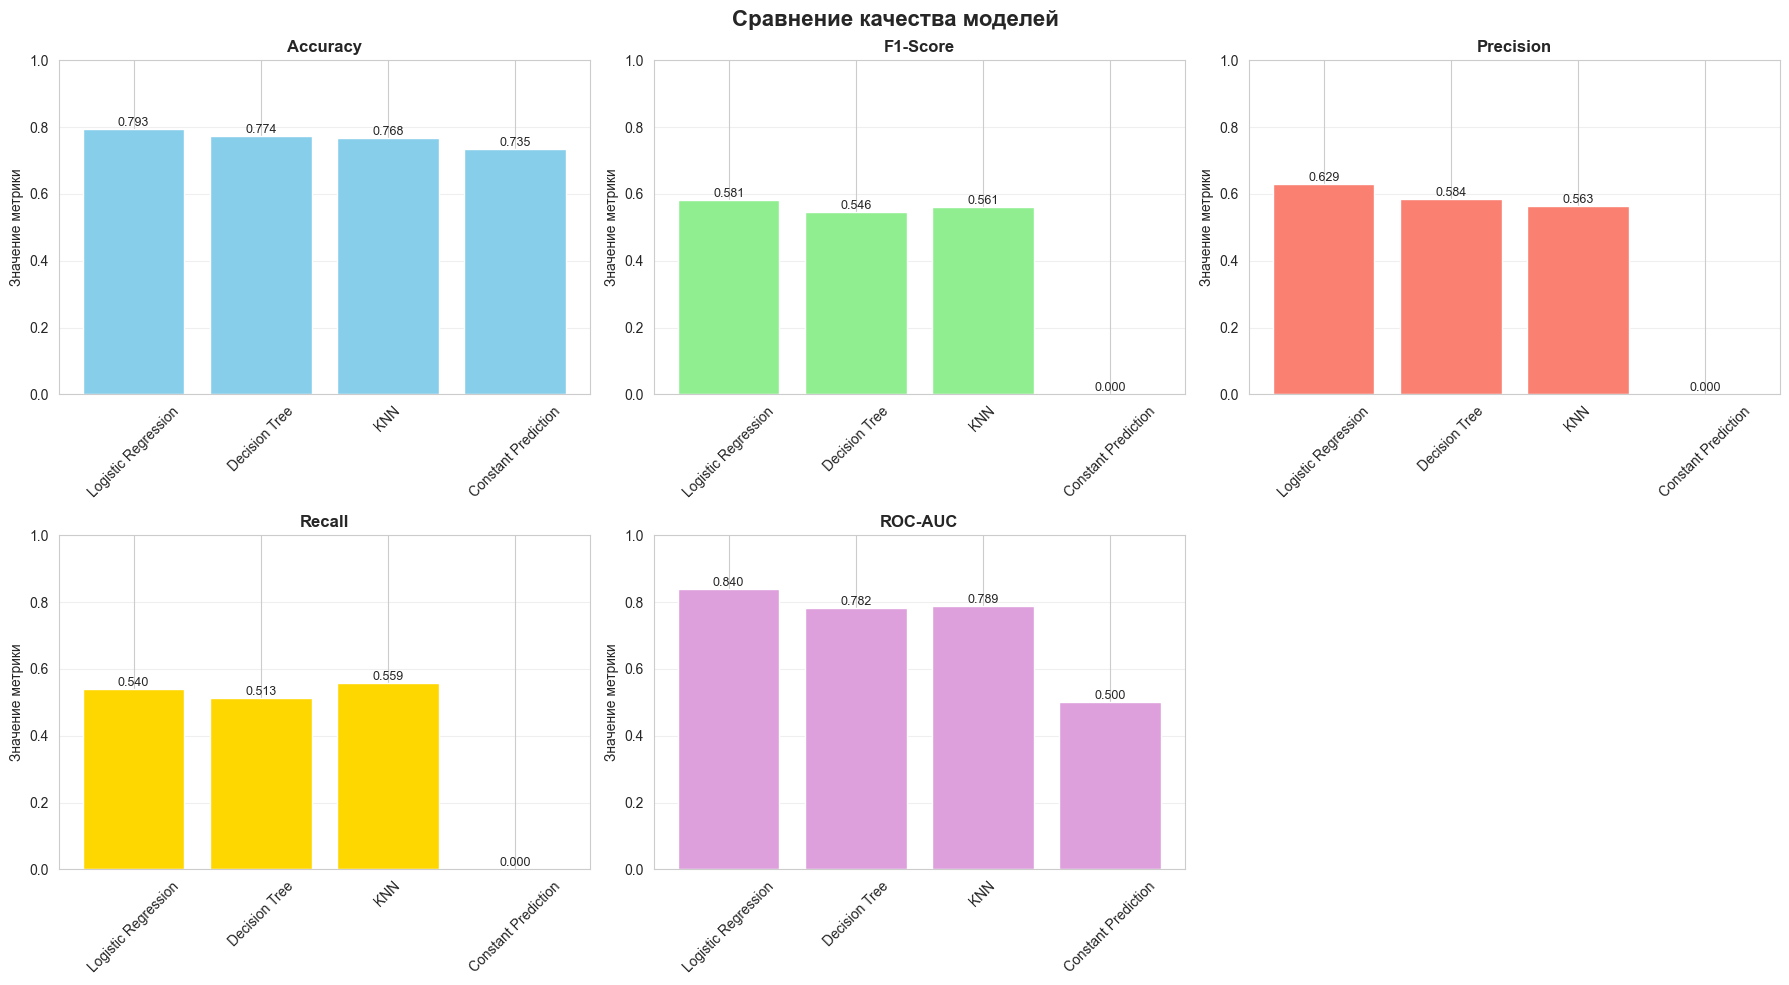

In [178]:
# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Сравнение качества моделей',
    fontsize=16,
    fontweight='bold'
)

metrics_to_plot = [
    'Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC'
]
colors = ['skyblue', 'lightgreen', 'salmon', 'gold', 'plum']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    bars = ax.bar(
        results_df['Model'],
        results_df[metric],
        color=colors[idx % len(colors)]
    )
    ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Значение метрики')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

# Скрываем последний subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


## 9. Детальный анализ лучшей модели

Выберем лучшую модель по F1-Score (основной метрике) и проведем детальный анализ её предсказаний.


In [179]:
# Находим лучшую модель по F1-Score (исключаем константное предсказание)
model_results = results_df[results_df['Model'] != 'Constant Prediction']
best_model_name = model_results.loc[model_results['F1-Score'].idxmax(), 'Model']

print(f"Лучшая модель по F1-Score: {best_model_name}")
print(f"\nДетальные метрики лучшей модели:")
best_metrics = model_results[model_results['Model'] == best_model_name].iloc[0]
for metric in ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'ROC-AUC']:
    print(f"  {metric}: {best_metrics[metric]:.4f}")


Лучшая модель по F1-Score: Logistic Regression

Детальные метрики лучшей модели:
  Accuracy: 0.7935
  F1-Score: 0.5813
  Precision: 0.6293
  Recall: 0.5401
  ROC-AUC: 0.8403


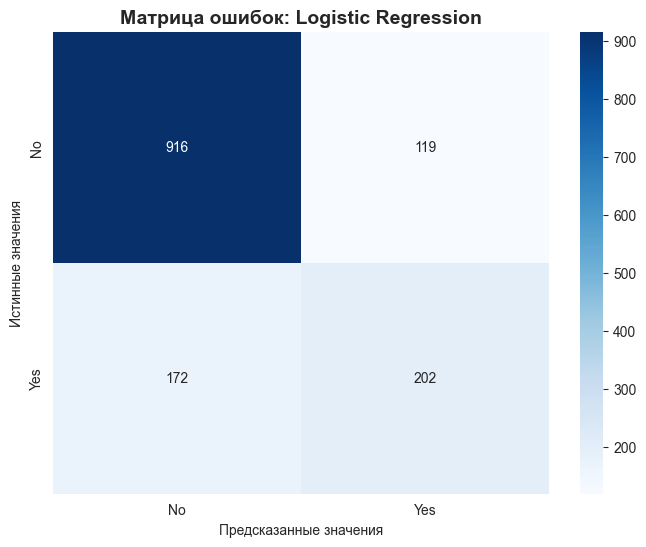

In [180]:
# Матрица ошибок для лучшей модели
best_model = trained_models[best_model_name]
y_pred_best = predictions[best_model_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=y_encoder.classes_,
    yticklabels=y_encoder.classes_
)
plt.title(
    f'Матрица ошибок: {best_model_name}',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

In [181]:
# Classification report для лучшей модели
print(f"\nДетальный отчет по классификации "
      f"({best_model_name}):")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=y_encoder.classes_,
    digits=4
))
print("="*70)



Детальный отчет по классификации (Logistic Regression):
              precision    recall  f1-score   support

          No     0.8419    0.8850    0.8629      1035
         Yes     0.6293    0.5401    0.5813       374

    accuracy                         0.7935      1409
   macro avg     0.7356    0.7126    0.7221      1409
weighted avg     0.7855    0.7935    0.7882      1409



Как и ожидалось, модель научилась лучше прогнозировать мажоритарный класс

## 10. Выводы

### Сравнение моделей с константным предсказанием

Все обученные модели превосходят константное предсказание по метрике F1-Score, что означает, что они действительно обучаются полезным паттернам из данных.

### Наилучший результат показала модель лог. регрессии
